In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [42]:

# 1. 데이터 불러오기 , 특성 선택
df = pd.read_csv('Mall_Customers.csv')

# 필요한 컬럼 추출
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X 


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


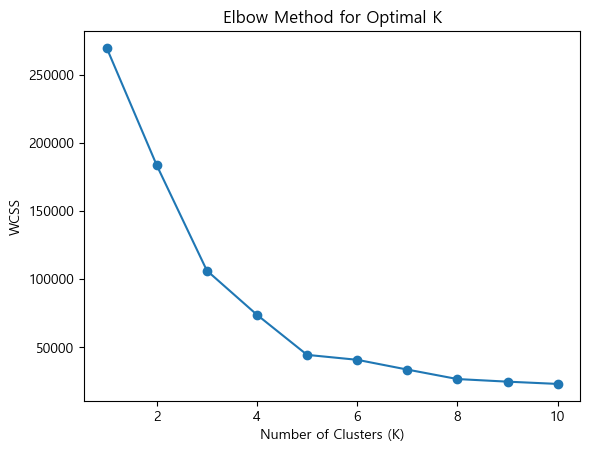

In [43]:
# 2. 최적의 클러스터 개수(k)찾기 엘보우 기법 (오차제곱합 WCSS 계산)
wcss = [] 
for k in range(1, 11): # 1~10까지 K-Means 모델 학습
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
        )
    
    kmeans.fit(X)

    wcss.append(kmeans.inertia_) # kmeans.inertia_속성 활용

# 엘보우 그래프 시각화
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()



In [44]:
# 3. K=5 모델 학습 및 예측
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
    )

y_kmeans = kmeans.fit_predict(X)



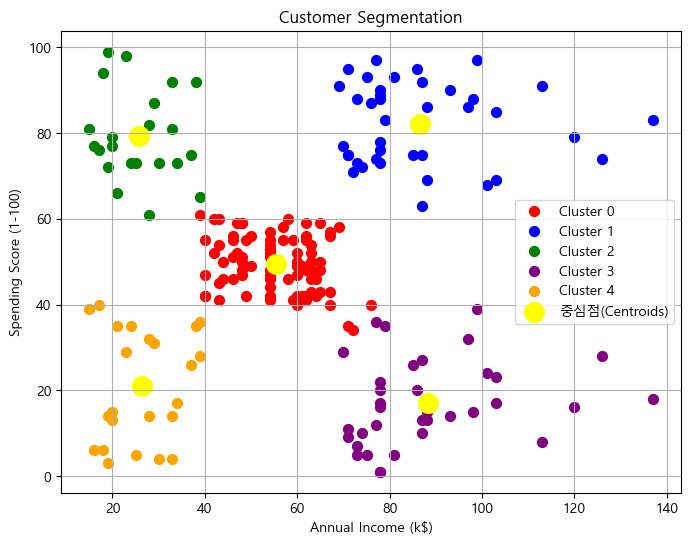

In [45]:
# 4. 군집 결과 시각화
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    plt.scatter(
        X[y_kmeans == i]['Annual Income (k$)'],
        X[y_kmeans == i]['Spending Score (1-100)'],
        s=50,
        c=colors[i],
        label=f'Cluster {i}'
    )

# 중심점
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='yellow',
    marker='o',
    label='중심점(Centroids)'
)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()

0 : 중간 소득 증긴 소비를 가짐 / 평균적인 고객들  
1 : 소득, 소비 모두 매우높음  / 고소득 고소비 고객들   
2 : 소득은 낮지만 소비가 매우 높음 / 소득은 낮은데 소비가 매우 큰 고객들    
3 : 소득은 높지만 소비가 낮은 고객들  / 소득이 높은데 소비가 낮은 고객들  
4 : 소득과 소비 둘다 낮은 고객층 / 저가치 고객들  